# House Price Prediction Application

## Project Overview
This notebook implements a house price prediction application using Random Forest regression. The model estimates the sale price of homes based on various features, including:
- SquareFeet
- Bedrooms
- Bathrooms
- Neighborhood (Rural, Suburb, Urban)
- YearBuilt

The dataset contains 50,000 rows of housing data for training and evaluation.

## 1. Setup and Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load and Inspect Data

In [4]:
# Load the housing dataset
housing_data = pd.read_csv('data/housing_price_dataset.csv')

print(f'Dataset loaded successfully!')
print(f'Total rows: {len(housing_data):,}')
print(f'Total colums: {len(housing_data.columns)}')
print(f'\nDataset shape: {housing_data.shape}')

Dataset loaded successfully!
Total rows: 50,000
Total colums: 6

Dataset shape: (50000, 6)


In [5]:
# Display first few rows
print('First 10 rows of the dataset:')
housing_data.head(10)

First 10 rows of the dataset:


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
5,2095,2,3,Suburb,2020,198208.803907
6,2724,2,1,Suburb,1993,343429.319110
7,2044,4,3,Rural,1957,184992.321268
8,2638,4,3,Urban,1959,377998.588152
9,1121,5,2,Urban,2004,95961.926014


In [6]:
# Data types
print('Data Types and Non-Null Counts:')
housing_data.info()

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [32]:
# Statistical summary
print('Statistical Summary of Numerical Features:')
housing_data.describe()

Statistical Summary of Numerical Features:


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [8]:
# Check for missing values
print('Missing Values per Column:')
missing_values = housing_data.isnull().sum()
print(missing_values)
print(f'\nTotal missing values: {missing_values.sum()}')

Missing Values per Column:
SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

Total missing values: 0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Features

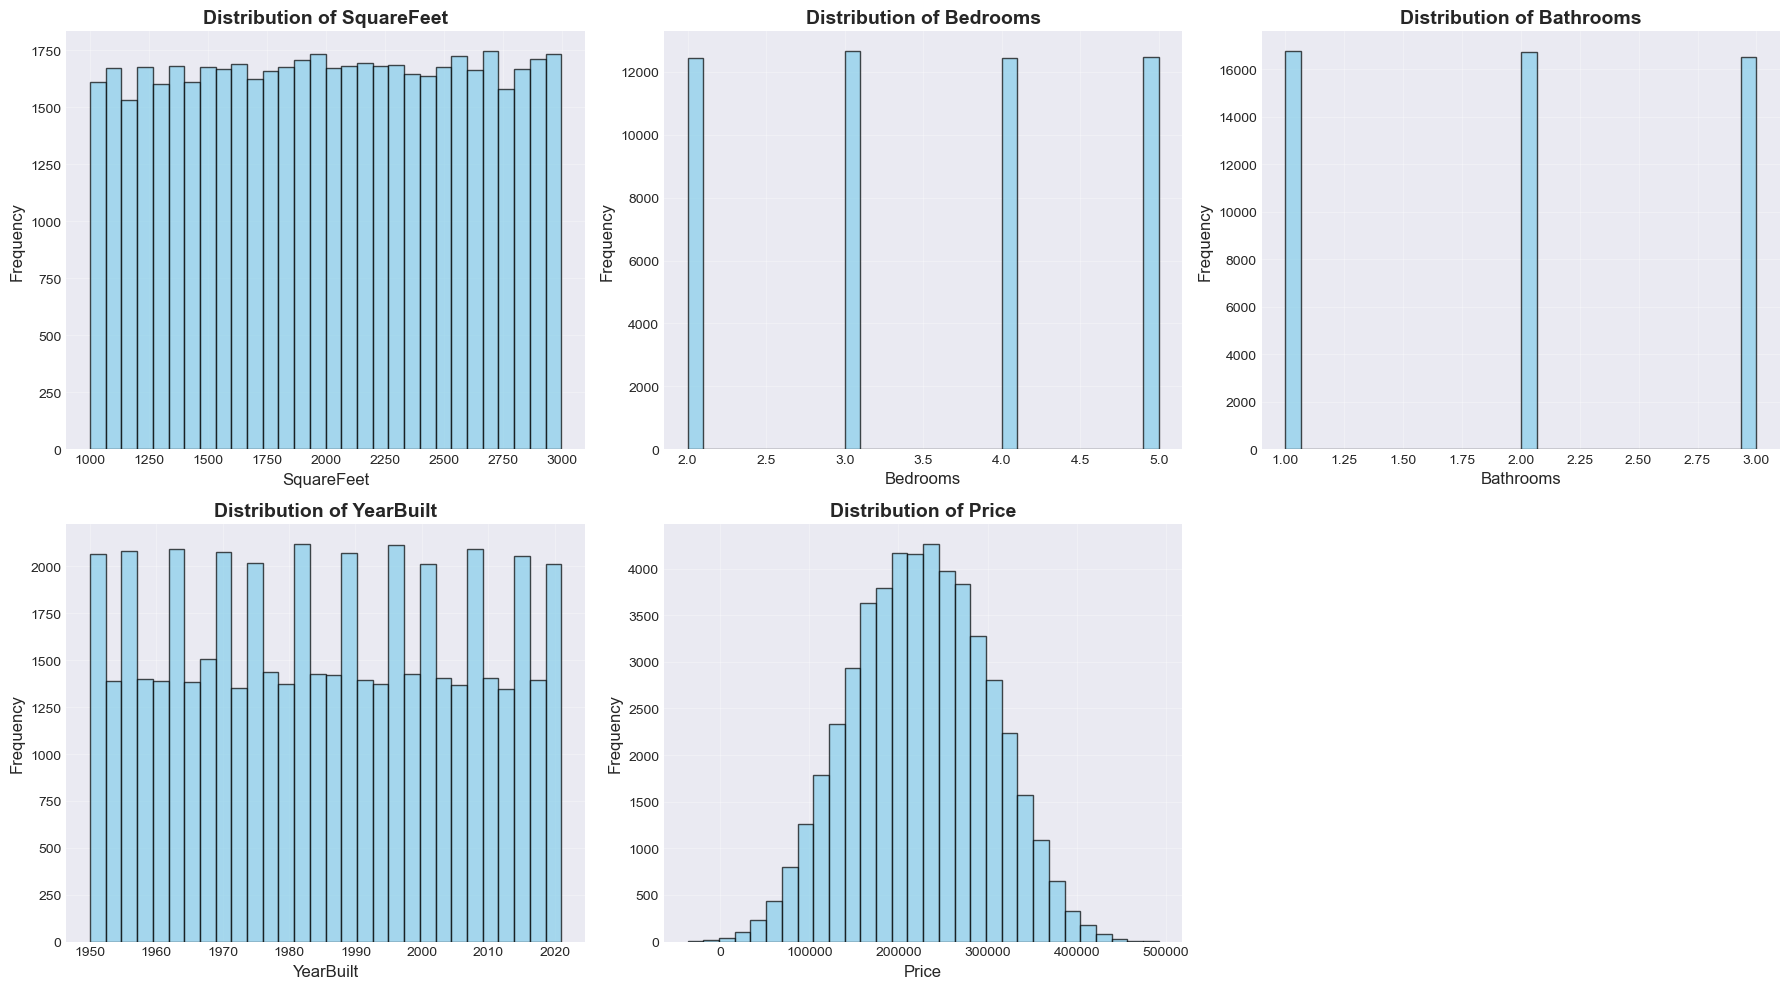

Histograms show the distribution of key features in the dataset.


In [11]:
# Histograms for numerical feature
numerical_features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.ravel()

for i, feature in enumerate(numerical_features):
    axes[i].hist(housing_data[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

print('Histograms show the distribution of key features in the dataset.')

### 3.2 Neighborhood Distribution

In [14]:
# Neighborhood value counts
print('Distribution of houses by Neighborhood:')
neighborhood_counts = housing_data['Neighborhood'].value_counts()
print(neighborhood_counts)
print(f'\nPercentages:')
print(housing_data['Neighborhood'].value_counts(normalize=True) * 100)

Distribution of houses by Neighborhood:
Neighborhood
Suburb    16721
Rural     16676
Urban     16603
Name: count, dtype: int64

Percentages:
Neighborhood
Suburb    33.442
Rural     33.352
Urban     33.206
Name: proportion, dtype: float64


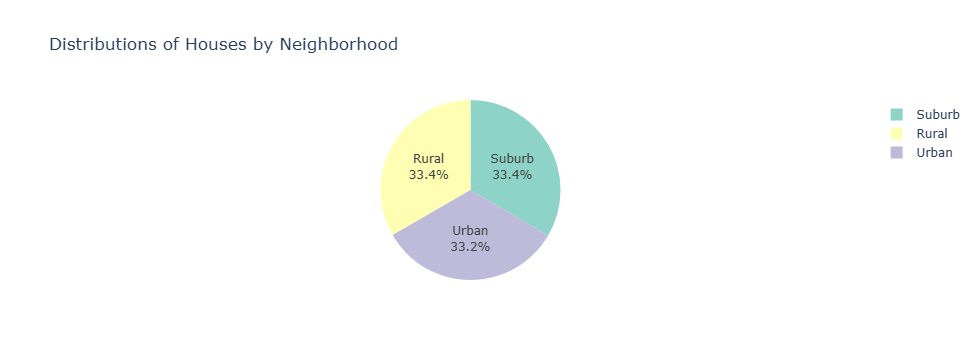

In [15]:
# Pie chart for neighborhood distribution
fig = px.pie(values=neighborhood_counts.values, names=neighborhood_counts.index, 
             title='Distributions of Houses by Neighborhood', color_discrete_sequence=px.colors.qualitative.Set3)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

### 3.3 Correlation Analysis

In [17]:
# Encode neighborhood for correlation analysis
housing_data_corr = housing_data.copy()
le_temp = LabelEncoder()
housing_data_corr['Neighborhood_encoded'] = le_temp.fit_transform(housing_data_corr['Neighborhood'])

# Calculate correlation matrix
correlation_features = ['SquareFeet', 'Bedrooms', 'Neighborhood_encoded', 'YearBuilt', 'Price']
corr_matrix = housing_data_corr[correlation_features].corr()

print('Correlation Matrix:')
print(corr_matrix)
print(f'\nCorrelation with Price:')
print(corr_matrix['Price'].sort_values(ascending=False))

Correlation Matrix:
                      SquareFeet  Bedrooms  Neighborhood_encoded  YearBuilt  \
SquareFeet              1.000000 -0.002638              0.011186   0.000482   
Bedrooms               -0.002638  1.000000             -0.004208   0.003147   
Neighborhood_encoded    0.011186 -0.004208              1.000000  -0.000174   
YearBuilt               0.000482  0.003147             -0.000174   1.000000   
Price                   0.750720  0.072624              0.016429  -0.002288   

                         Price  
SquareFeet            0.750720  
Bedrooms              0.072624  
Neighborhood_encoded  0.016429  
YearBuilt            -0.002288  
Price                 1.000000  

Correlation with Price:
Price                   1.000000
SquareFeet              0.750720
Bedrooms                0.072624
Neighborhood_encoded    0.016429
YearBuilt              -0.002288
Name: Price, dtype: float64


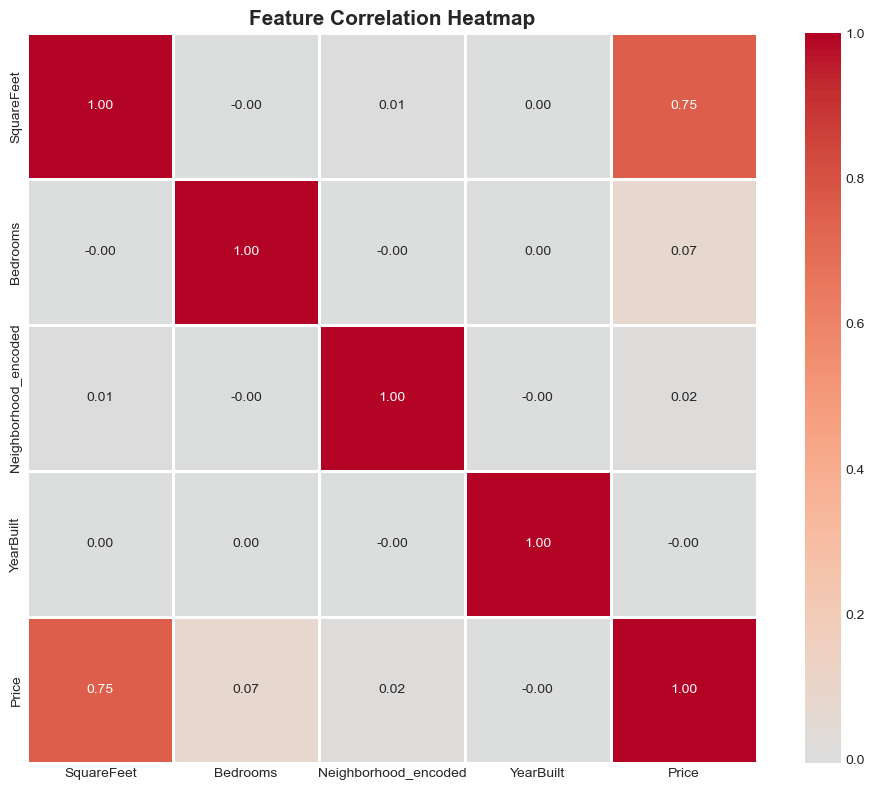

In [21]:
# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Scatter Plots: Features vs Price

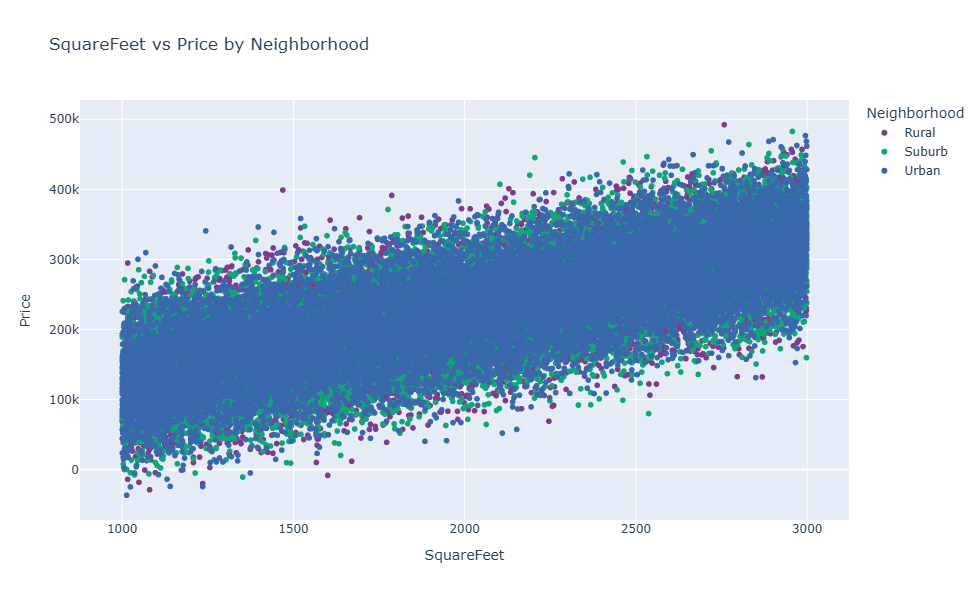

In [25]:
# SquareFeet vs Price by Neighborhood
fig = px.scatter(housing_data, x='SquareFeet', y='Price', color='Neighborhood', title='SquareFeet vs Price by Neighborhood',
                 hover_data=['Bedrooms', 'Bathrooms', 'YearBuilt'], color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(height=600)
fig.show()

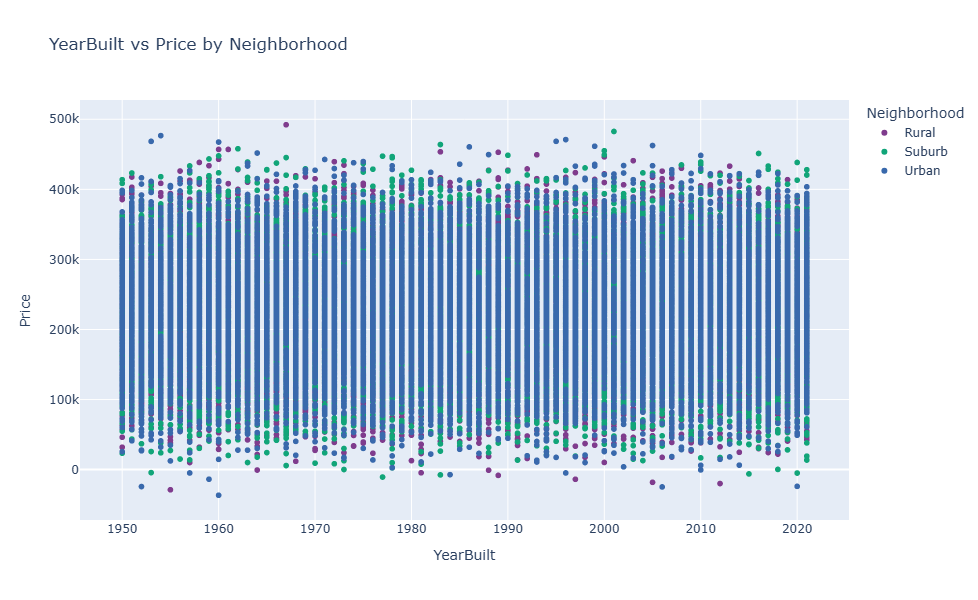

In [26]:
# YearBuilt vs Price by Neighborhood
fig = px.scatter(housing_data, x='YearBuilt', y='Price', color='Neighborhood', title='YearBuilt vs Price by Neighborhood',
                 hover_data=['SquareFeet', 'Bedrooms', 'Bathrooms'], color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(height=600)
fig.show()

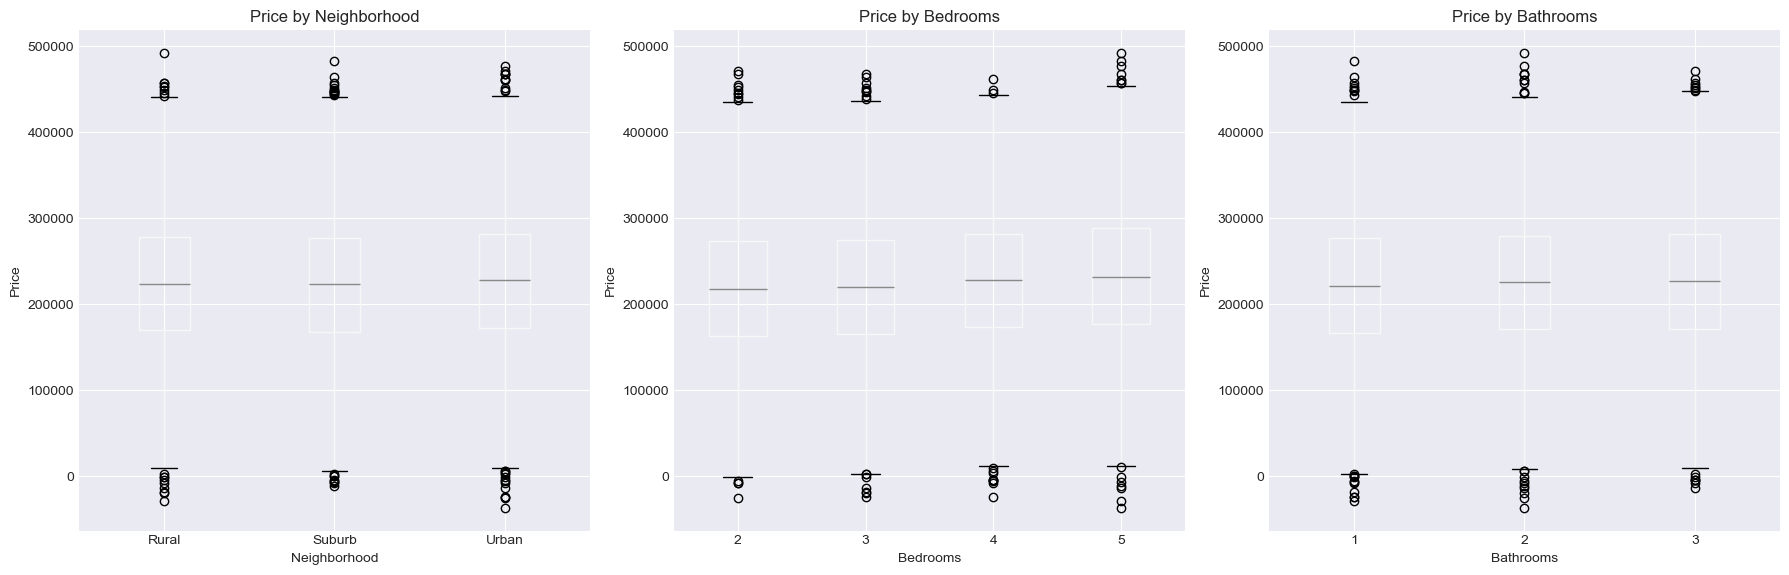

In [29]:
# Box plots: Price by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Price by Neighborhood
housing_data.boxplot(column='Price', by='Neighborhood', ax=axes[0])
axes[0].set_title('Price by Neighborhood')
axes[0].set_xlabel('Neighborhood')
axes[0].set_ylabel('Price')

# Price by Bedrooms
housing_data.boxplot(column='Price', by='Bedrooms', ax=axes[1])
axes[1].set_title('Price by Bedrooms')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price')

# Price by Bathrooms
housing_data.boxplot(column='Price', by='Bathrooms', ax=axes[2])
axes[2].set_title('Price by Bathrooms')
axes[2].set_xlabel('Bathrooms')
axes[2].set_ylabel('Price')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Model Training

### 4.1 Encode Categorical Variables

In [31]:
# Create a copy for modeling
housing_data_model = housing_data.copy()

# Encode Neighborhood using Label Encoding
le = LabelEncoder()
housing_data_model['Neighborhood_encoded'] = le.fit_transform(housing_data_model['Neighborhood'])

print('Neighborhood encoding:')
for i, neighborhood in enumerate(le.classes_):
    print(f'{neighborhood}: {i}')

print('\nEncoded Neighborhood column added successfully!')

Neighborhood encoding:
Rural: 0
Suburb: 1
Urban: 2

Encoded Neighborhood column added successfully!


### 4.2 Split Data into Training and Test Sets

In [33]:
# Define features and target
features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood_encoded', 'YearBuilt']
X = housing_data_model[features]
y = housing_data_model['Price']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data split completed!')
print(f'Training samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')
print(f'Features used: {len(features)}')
print(f'\nFeatures: {features}')

Data split completed!
Training samples: 40,000
Test samples: 10,000
Features used: 5

Features: ['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood_encoded', 'YearBuilt']


### 4.3 Train Random Forest Regressor

In [34]:
# Initialize and train the Random Forest model
print('Training Random Forest Regressor...')

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

print('\nModel training completed successfully!')

Training Random Forest Regressor...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.8s



Model training completed successfully!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.4s finished


### 4.4 Feature Importance

Feature Importance:
        Feature  Importance
0    SquareFeet    0.742495
4     YearBuilt    0.157187
3  Neighborhood    0.037386
2     Bathrooms    0.033524
1      Bedrooms    0.029408


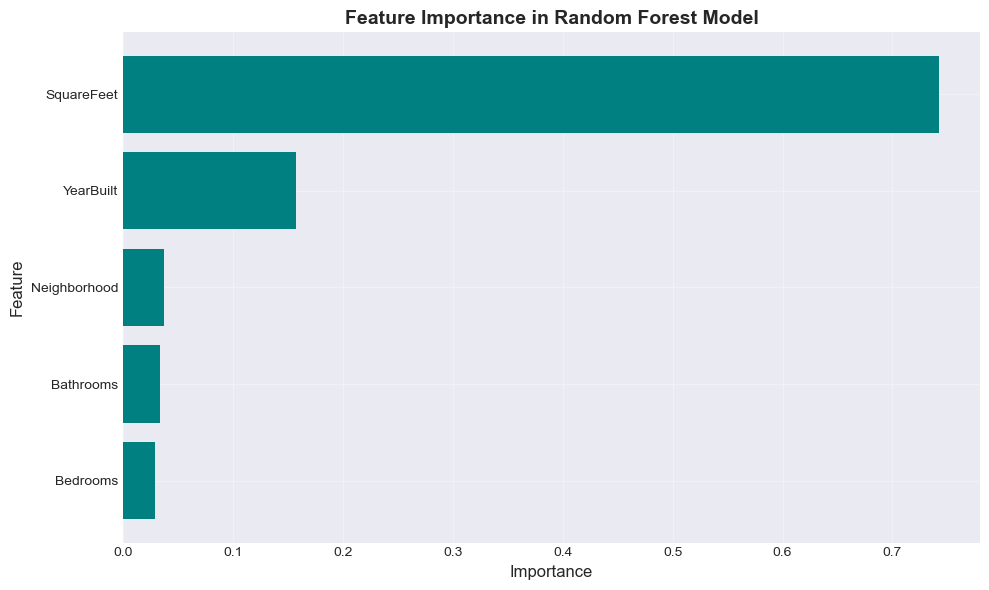

In [35]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': ['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt'],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance:')
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Random Forest Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Model Evaluation

### 5.1 Make Predictions on Test Set

In [37]:
# Make predictions on test data
y_pred = rf_model.predict(X_test)

print('Predictions completed!')
print(f'Sample predictions (first 10):')
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10],
    'Difference': y_test.values[:10] - y_pred[:10]
})
print(comparison)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished


Predictions completed!
Sample predictions (first 10):
    Actual Price  Predicted Price    Difference
0  170835.035713    225502.048319 -54667.012606
1  126913.469998    145790.730757 -18877.260759
2  246611.883092    276660.295411 -30048.412319
3  244250.462969    323591.390532 -79340.927563
4  271127.650112    275815.394484  -4687.744372
5  189289.951199    221440.262488 -32150.311289
6  343510.576500    297216.182459  46294.394041
7  203461.591080    190730.942666  12730.648414
8  285903.247682    301097.120034 -15193.872352
9  224868.958375    247028.979830 -22160.021455


### 5.2 Performance Metrics

In [39]:
# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('-' * 60)
print('MODEL PERFORMANCE METRICS')
print('-' * 60)
print(f'Root Mean Square Error (RMSE): ${rmse:,.2f}')
print(f'Mean Absolute Error (MAE):     ${mae:,.2f}')
print(f'R2 Score:                      {r2:.4f}')
print('>' * 60)
print('\nMetric Interpretations:')
print(f'- RMSE: Average Prediction error is ${rmse:,.2f}')
print(f'- MAE: Average absolute difference is ${mae:,.2f}')
print(f'- R2: Model explains {r2*100:.2f}% of variance in house prices')
print('  (R2 closer to 1.0 indicates better model performance)')

------------------------------------------------------------
MODEL PERFORMANCE METRICS
------------------------------------------------------------
Root Mean Square Error (RMSE): $52,623.29
Mean Absolute Error (MAE):     $41,962.72
R2 Score:                      0.5176
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

Metric Interpretations:
- RMSE: Average Prediction error is $52,623.29
- MAE: Average absolute difference is $41,962.72
- R2: Model explains 51.76% of variance in house prices
  (R2 closer to 1.0 indicates better model performance)


### 5.3 Predicted vs Actual Prices

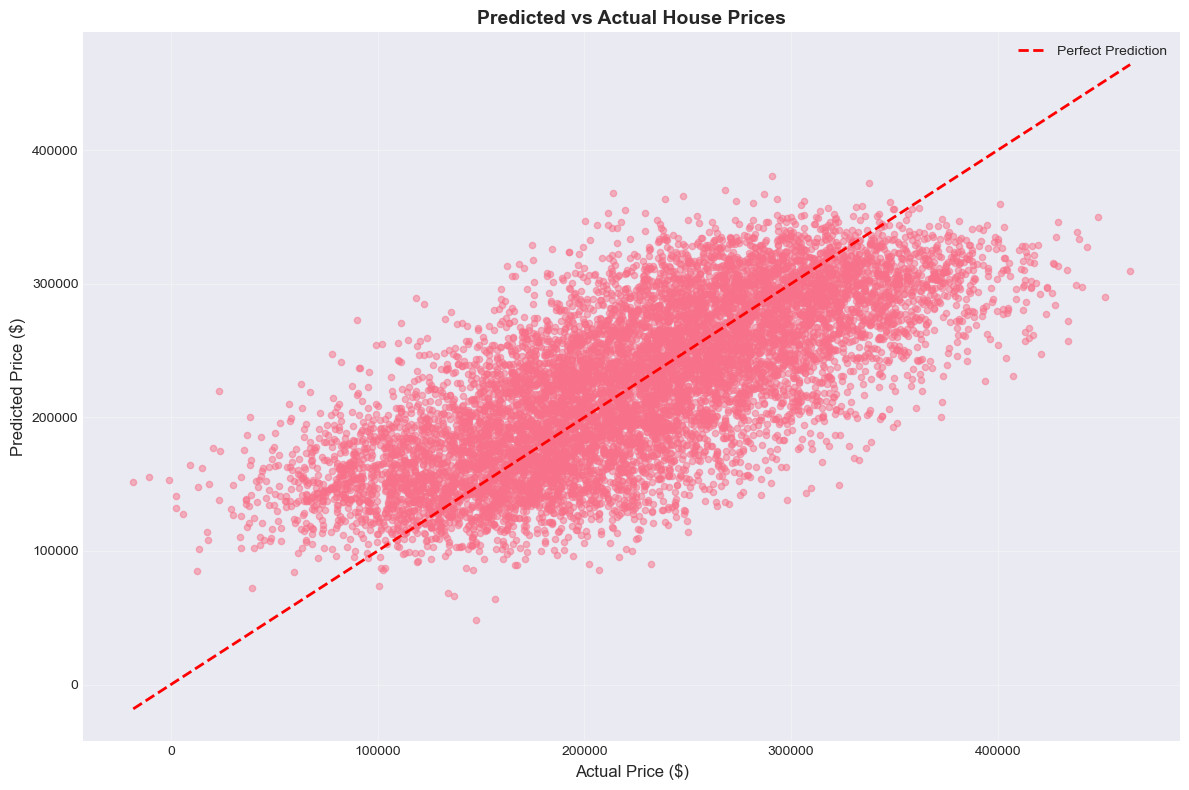

Points closer to the red line indicate better predictions.


In [40]:
# Scatter Plot: Predicted vs Actual
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Predicted vs Actual House Prices', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Points closer to the red line indicate better predictions.')

### 5.4 Residuals Analysis

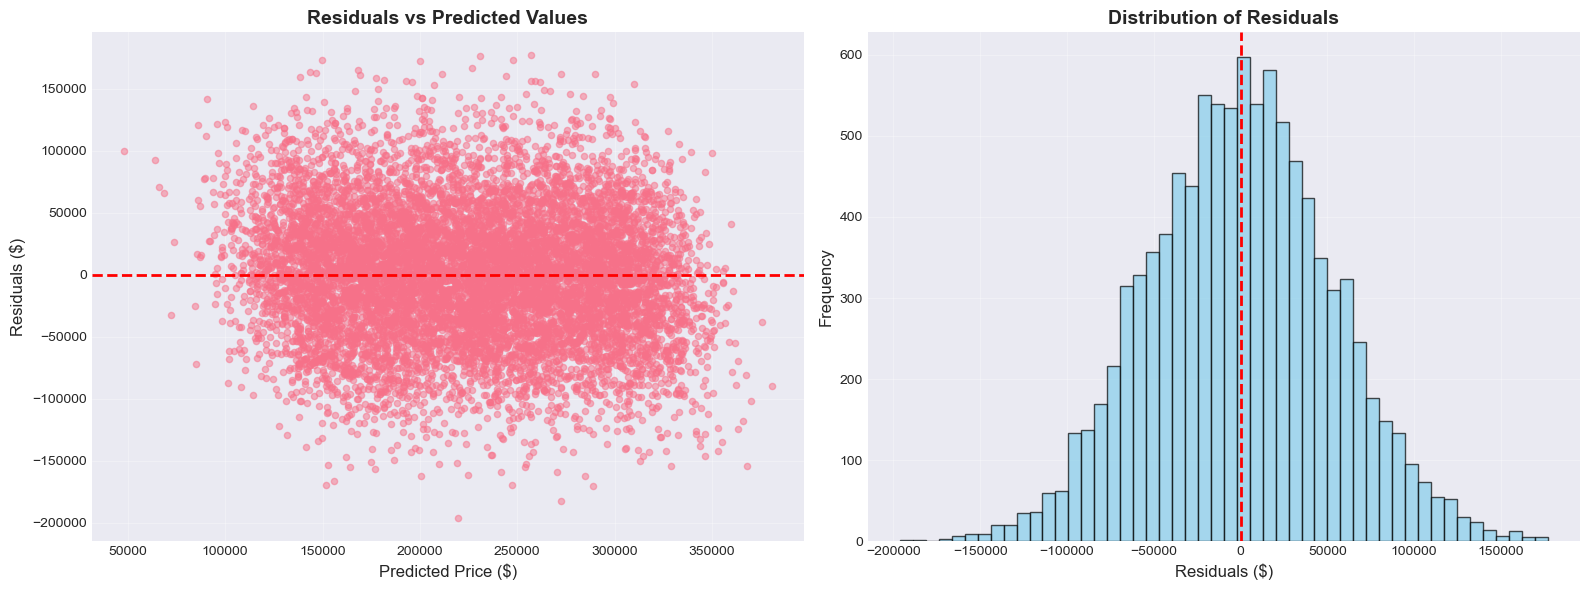

Mean Residual: $-77.78
Std Residual: $52,625.87


In [41]:
# Calculate residuals
residuals = y_test - y_pred

# Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Predicted Values
axes[0].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0].set_ylabel('Residuals ($)', fontsize=12)
axes[0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distribution of Residuals
axes[1].hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean Residual: ${residuals.mean():,.2f}')
print(f'Std Residual: ${residuals.std():,.2f}')

### 5.5 Error Distribution

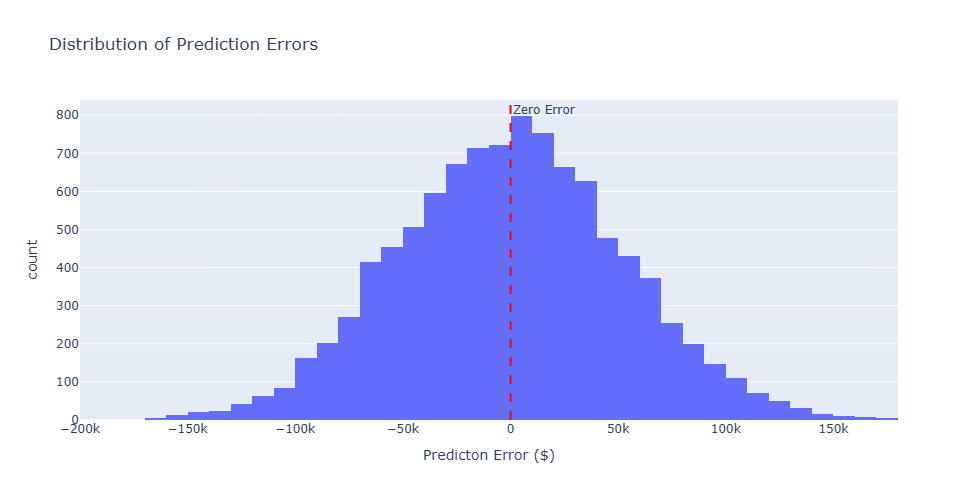

In [44]:
# Interactive histogram of prediction errors
fig = px.histogram(x=residuals, nbins=50, title='Distribution of Prediction Errors',
                   labels={'x': 'Predicton Error ($)', 'y': 'Frequency'})
fig.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Zero Error")
fig.update_layout(height=500)
fig.show()

## 6. Interactive Price Prediction

### 6.1 Predict Price for Custom House Features

You can manually input house features below in section 6.2 to get price predictions from the trained model.

In [51]:
# Predicts house price based on input features
def predict_house_price(square_feet, bedrooms, bathrooms, neighborhood, year_built):
    
    # Encode neighborhood
    neighborhood_encoded = le.transform([neighborhood])[0]

    # Create feature array
    features_input = np.array([[square_feet, bedrooms, bathrooms, neighborhood_encoded, year_built]])

    # Make prediction
    prediction = rf_model.predict(features_input)[0]

    # Display results
    print('-' * 60)
    print('HOUSE PRICE PREDICTION')
    print('-' * 60)
    print(f'Square Feet:     {square_feet:,}')
    print(f'Bedrooms:        {bedrooms}')
    print(f'Bathrooms:       {bathrooms}')
    print(f'Neighborhod:     {neighborhood}')
    print(f'Year Built:      {year_built}')
    print('>' * 60)
    print(f'PREDICTED PRICE: ${prediction:,.2f}')
    print('-' * 60)

    return prediction


### 6.2 Make Your Manual Predictions

Modify the values below and run the cell to get a prediction for manual inputs:

In [52]:
# Modify these values to get manual predictions
m_square_feet = 2500
m_bedrooms = 4
m_bathrooms = 3
m_neighborhood = 'Urban'   # Options: 'Rural', 'Suburb', 'Urban'
m_year_built = 2015        # Min: '1950,  Max: '2021

# Get prediction
m_prediction = predict_house_price(
    square_feet=m_square_feet,
    bedrooms=m_bedrooms,
    bathrooms=m_bathrooms,
    neighborhood=m_neighborhood,
    year_built=m_year_built
)

------------------------------------------------------------
HOUSE PRICE PREDICTION
------------------------------------------------------------
Square Feet:     2,500
Bedrooms:        4
Bathrooms:       3
Neighborhod:     Urban
Year Built:      2015
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
PREDICTED PRICE: $276,678.76
------------------------------------------------------------


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


### 6.3 Batch Predictions from Test Dataset

You can also make batch test predictions on rows form the reserved test dataset:

In [59]:
# Get random samples from the test set
sample_indices = np.random.choice(len(X_test), 10, replace=False)
X_sample = X_test.iloc[sample_indices]
y_sample_actual = y_test.iloc[sample_indices]
y_sample_pred = rf_model.predict(X_sample)

# Display predictions
print('Sample Predictions from Test Dataset:\n')
results_df = pd.DataFrame({
    'SquareFeet': X_sample['SquareFeet'].values,
    'Bedrooms': X_sample['Bedrooms'].values,
    'Bathrooms': X_sample['Bathrooms'].values,
    'YearBuilt': X_sample['YearBuilt'].values,
    'Actual Price': y_sample_actual.values,
    'Predicted Price': y_sample_pred,
    'Error': y_sample_actual.values - y_sample_pred,
    'Error %': ((y_sample_actual.values - y_sample_pred) / y_sample_actual.values * 100)
})

# Format currency columns
results_df['Actual Price'] = results_df['Actual Price'].apply(lambda x: f'${x:,.2f}')
results_df['Predicted Price'] = results_df['Predicted Price'].apply(lambda x: f'${x:,.2f}')
results_df['Error'] = results_df['Error'].apply(lambda x: f'${x:,.2f}')
results_df['Error %'] = results_df['Error %'].apply(lambda x: f'{x:.2f}%')

print(results_df.to_string(index=False))

Sample Predictions from Test Dataset:

 SquareFeet  Bedrooms  Bathrooms  YearBuilt Actual Price Predicted Price       Error Error %
       2065         3          1       1973  $219,879.67     $209,396.12  $10,483.56   4.77%
       2011         3          3       1953  $277,615.39     $258,212.72  $19,402.67   6.99%
       2580         3          3       1998  $308,422.58     $280,846.27  $27,576.31   8.94%
       1927         3          3       1993  $269,435.44     $193,085.46  $76,349.98  28.34%
       2255         5          1       1984  $244,334.33     $257,779.61 $-13,445.27  -5.50%
       1584         2          2       2002   $94,874.49     $189,682.65 $-94,808.15 -99.93%
       2321         3          3       1989  $222,928.06     $249,331.50 $-26,403.44 -11.84%
       2668         5          2       1973  $327,266.30     $303,765.55  $23,500.75   7.18%
       1442         4          1       1970  $198,057.68     $143,208.49  $54,849.19  27.69%
       1486         2          

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
